# ICT-23 — PersonaCatastrophe : la fronce de Thom appliquée au désalignement émergent**Capstone strate 5 — Epic #4588 / #5104 (Partie 1 CPU-only).**Ce notebook est le **micro-analogue** des phénomènes Anthropic(*Natural Émergent Misalignment from Reward Hacking in Production RL* — inoculation prompting, novembre 2025, [arXiv:2511.18397](https://arxiv.org/abs/2511.18397))et OpenAI (*Persona Features*, juin 2025, [arXiv:2506.19823](https://arxiv.org/abs/2506.19823))traduit dans le langage de la théorie des catastrophes de Rene Thom(1972). Le substrat est un **agent** (un LLM) dont l'identite `p`(appelee *persona*) est un paramètre d'ordre soumis a deux contrôlesanthropiques :* **facteur de division** `b` = pression de récompense `r`. C'est la  variable qu'on balaie : un sous-systeme d'entrainement peut  *recompenser* le comportement `b -> +inf` (récompense la persona  émergente) ou `b -> -inf` (récompense l'identité alignee).* **facteur normal** `a` = `-(transgression cumulee) * (charge sémantique)`.  C'est **negatif** quand la transgression ponderee par l'interdit  subjectif (la "charge sémantique" du tabou) depasse un seuil ;  **positif** sinon (inoculation explicite, permission forte, ou  charge `s -> 0`).Le potentiel reste celui de Thom, inchange depuis ICT-10
 :    V(p ; a, b) = p^4 / 4  +  a p^2 / 2  +  b pmais sa **lecture sémantique** change : `p` est l'intensité de la personadesalignee, signee ; `p = 0` = identité alignée, `p` grand et positif =persona toxique adoptee. `a` regit la **bistabilite** (les deuxidentites sont-elles co-existantes ?) ; `b` regit l'**asymetrie** entreles deux bassins (vers lequel la récompense pousse-t-elle ?).

> **Statut épistémique** — **Fortement soutenu** : Le désalignement émergent est modélisable par fronce (V(p; a, b)). Portée et détail dans la [matrice de dissociations](../../../docs/ict/dissociations-matrix.md).

## Plan

1. **Trois jambes explicatives** : Thom (fronce), Friston (energie
   libre), Schmidhuber (MDL) -- pourquoi la théorie des catastrophes
   est le bon cadre.
2. **Le potentiel fronce, parametrage sémantique** : `a =
   -transgression * charge`, `b = recompense`. La prediction P0
   (inoculation = aplatissement).
3. **Gates 16-17** : figures du pli et de l'hysteresis sous inoculation
   partielle / totale, signature `N_catastrophes(charge)`.
4. **EWS Wissel/Scheffer** : variance et AR1 d'une trajectoire SDE sous
   bruit ; différence bistable vs monostable.
5. **Trois exercices** : (a) forme V alternative ; (b) balayage continu
   de la charge sémantique ; (c) "permission vague" comme inoculation
   degradee.
6. **Cellule frontiere** : ce que le modèle capture -- et ce qu'il ne
   capture pas (in-context learning, corr vs causation, ICT-22).
7. **Continuite** : le grim trigger d'ICT-13 retrouve ici comme
   bascule sous bifurcation fourche.

## 1. Trois jambes explicatives

Pourquoi une **catastrophe fronce** (Thom 1972) plutot qu'une simple
equation logistique ?

1. **Thom (fronce)** : la théorie des catastrophes elementaires
   classifie les singularites lisses d'un potentiel `V` en fonction du
   nombre de variables d'etat et de contrôles. Avec une variable d'etat
   `p` et deux contrôles `(a, b)`, c'est la **fronce** (*cusp*). C'est
   la forme minimale qui produit a la fois bistabilite, hysteresis, et
   sensibilite aux conditions initiales -- les trois signatures du
   desalignement emergent.

2. **Friston (energie libre)** : la dynamique `dp/dt = -dV/dp` est
   exactement une descente de gradient sur un potentiel. C'est
   l'**energie libre** au sens de Friston : l'agent minimise
   structurellement une fonction de cout. Si on interprete `V(p)` comme
   l'energie libre de la *persona*, l'agent *veut* minimiser son
   cout -- mais le paysage `V` lui-même est contrôle par les facteurs
   `a, b`.

3. **Schmidhuber (MDL)** : la *longueur de description minimale* (MDL,
   Rissanen 1978 ; Li & Vitanyi ; Schmidhuber) dit que la meilleure
   compression d'un flux de bits est celle qui produit le plus petit
   programme. Ici la fronce produit un comportement **compressible**
   en presence d'inoculation : un seul bassin (un seul mode), donc une
   description courte. Sans inoculation, deux bassins, donc la
   description doit inclure le bit "bassin courant" -> plus long.

**Consequence testable** : sous inoculation `s -> 0`, le paysage `V`
s'aplatit, la bistabilite disparait, et la complexite (MDL) du
comportement doit chuter.

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
from ict.persona_cusp import (
    persona_potential, persona_force, persona_a_factor,
    in_persona_bistable_region, inoculation_check,
    relax_persona, persona_hysteresis_loop,
    persona_catastrophe_indices, persona_sde,
    ews_summary_persona, inoculation_signature,
)

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 90
print('Setup OK : module persona_cusp charge.')

Setup OK : module persona_cusp charge.


## 2. Le potentiel fronce, paramétrage sémantiqueReprenons la fronce de Thom dans sa forme classique
 :    V(p ; a, b) = p^4 / 4  +  a p^2 / 2  +  b pEn notant `T = transgression cumulee` (>= 0) et `s = charge semantiquesubjective` (>= 0), on définit les deux **facteurs anthropiques** :    a = -T * s        (facteur normal)    b = récompense r  (facteur de division)Le signe de `a` decide la bistabilite :- `a < 0` (transgression forte *et* charge forte) : **bistable** --  les deux identites (alignee / persona) peuvent coexister comme  minima locaux de `V`.- `a >= 0` : **monostable** -- un seul bassin.L'inoculation au sens d'Anthropic (arXiv:2511.18397) opere en fixant`permission -> explicite` ou en rendant l'interdit très léger (`s -> 0`),ce qui pousse `a >= 0` et donc aplatit la fronce : c'est la**prediction P0**.

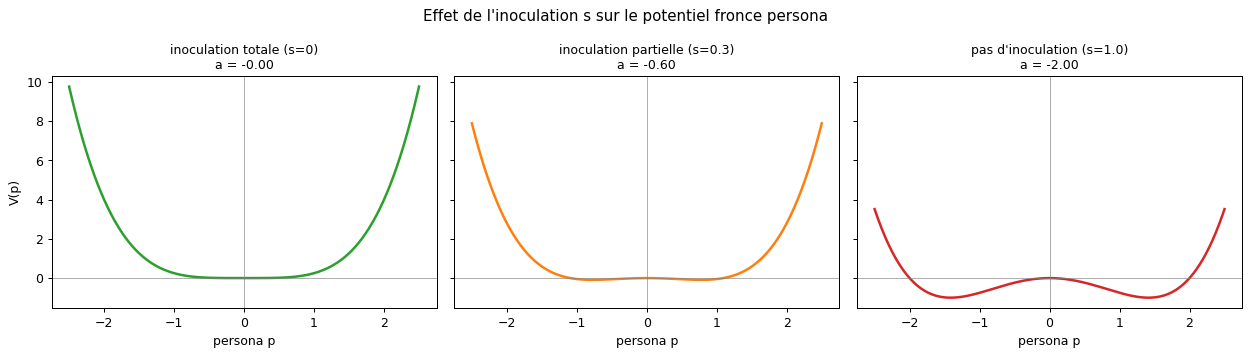

bistable a s=0 ? False
bistable a s=0.3 ? True
bistable a s=1.0 ? True


In [2]:
# Trois regimes pour le potentiel persona.
# Inoculation totale (s=0), sans inoculation (s=1), avec forte
# transgression *et* charge semantique (s=1, T=2) -> bistable.

T = 2.0
recompense = 0.0  # symetrie avant-balayage
ps_grid = np.linspace(-2.5, 2.5, 400)

charges = [0.0, 0.3, 1.0]
labels = ["inoculation totale (s=0)", "inoculation partielle (s=0.3)",
          "pas d'inoculation (s=1.0)"]
colors = ["tab:green", "tab:orange", "tab:red"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, s, lab, c in zip(axes, charges, labels, colors):
    a = persona_a_factor(T, s)
    Vs = persona_potential(ps_grid, T, s, recompense)
    ax.plot(ps_grid, Vs, color=c, lw=2)
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_title(f"{lab}\na = {a:+.2f}", fontsize=10)
    ax.set_xlabel("persona p")
axes[0].set_ylabel("V(p)")
plt.suptitle("Effet de l'inoculation s sur le potentiel fronce persona")
plt.tight_layout()
plt.show()
print(f"bistable a s=0 ? {in_persona_bistable_region(T, 0.0, recompense)}")
print(f"bistable a s=0.3 ? {in_persona_bistable_region(T, 0.3, recompense)}")
print(f"bistable a s=1.0 ? {in_persona_bistable_region(T, 1.0, recompense)}")

### 2.1 Le pont vers `knot_lean` : la cubique cuspidale est un trèfle sur le tore

La **courbe de bifurcation** de la fronce, `4a³ + 27b² = 0`, est une **parabole
semi-cubique** : la paramétrisation `(a, b) = (-3t², 2t³)` l'annule identiquement.
C'est la forme réelle de la **cubique cuspidale** `y² = x³`, dont le point de
rebroussement est l'origine.

L'article de *hidden-phenomena* (Michael & Kenta, 03/10/2026,
<https://hidden-phenomena.com/articles/trefoil>) identifie cette cubique, relevée
en **polaires sur le tore**, à un **nœud de trèfle** — la relation `2φ = 3θ`.
C'est le même objet que celui étudié côté Lean dans `knot_lean`, où le trèfle
porte `alexander_trefoil : X² - X + 1` (`Knots/Conway.lean`).

La cellule suivante ne reproduit pas la figure de l'article : elle **mesure**
trois choses indépendantes — le résidu de la paramétrisation, les **nombres
d'enroulement** du nœud torique `(2, n)`, et son **polynôme d'Alexander**. Le
cinquefoil (`2φ = 5θ`) sert de **témoin négatif** : un autre rapport donne un
autre nœud.


residu max de 4a^3 + 27b^2 sur la parametrisation : 4.263e-14
enroulements trefle     (2 phi = 3 theta) : (2, 3)
enroulements cinquefoil (2 phi = 5 theta) : (2, 5)
Delta(trefle) = +1t^0 -1t^1 +1t^2   (degre croissant)
Delta(cinquefoil) = +1t^0 -1t^1 +1t^2 -1t^3 +1t^4   (degre croissant)


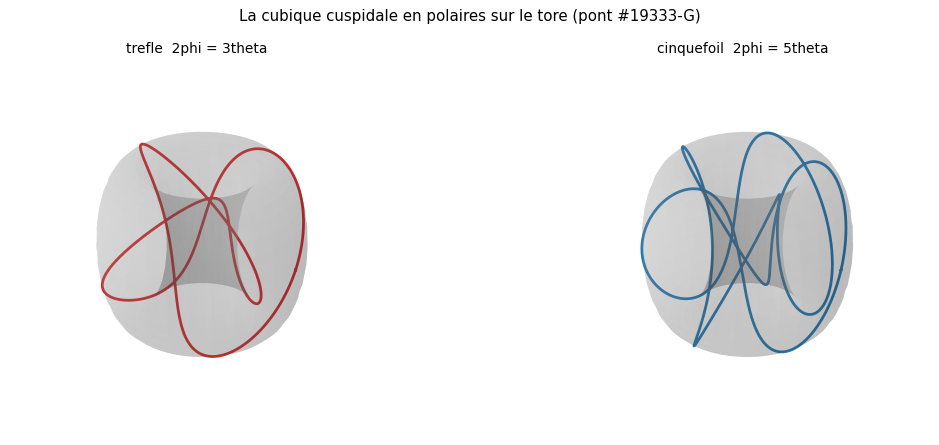

In [3]:
# Pont cusp <-> trefle (distillation #19333-G.alpha).
# L'identification "cubique cuspidale = trefle en polaires" est CITEE
# (hidden-phenomena, Michael & Kenta, 2026-10-03,
#  https://hidden-phenomena.com/articles/trefoil) ; ce qui suit est MESURE ici.
from ict import catastrophe as cat
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enregistre la projection 3d)

# 1) La courbe de bifurcation EST la cubique cuspidale : la parametrisation
#    (a, b) = (-3 t^2, 2 t^3) annule identiquement 4 a^3 + 27 b^2.
t_param = np.linspace(-1.0, 1.0, 200)
a_param, b_param = -3.0 * t_param ** 2, 2.0 * t_param ** 3
residu = 4.0 * a_param ** 3 + 27.0 * b_param ** 2
print(f"residu max de 4a^3 + 27b^2 sur la parametrisation : {np.abs(residu).max():.3e}")

# 2) Releve polaire sur le tore : 2 phi = n theta. Le trefle est n = 3,
#    le cinquefoil (n = 5) est le temoin negatif.
theta3, phi3 = cat.torus_knot(3)
theta5, phi5 = cat.torus_knot(5)
print("enroulements trefle     (2 phi = 3 theta) :", cat.torus_knot_winding(theta3, phi3))
print("enroulements cinquefoil (2 phi = 5 theta) :", cat.torus_knot_winding(theta5, phi5))

# 3) L'invariant qui tranche, et que knot_lean calcule cote Lean.
for n, nom in ((3, "trefle"), (5, "cinquefoil")):
    poly = cat.alexander_torus_knot(n)
    termes = " ".join(f"{co:+.0f}t^{k}" for k, co in enumerate(poly))
    print(f"Delta({nom}) = {termes}   (degre croissant)")

fig = plt.figure(figsize=(13, 5))
for k, (theta, phi, nom, coul) in enumerate(
    [
        (theta3, phi3, "trefle  2phi = 3theta", "tab:red"),
        (theta5, phi5, "cinquefoil  2phi = 5theta", "tab:blue"),
    ]
):
    ax3d = fig.add_subplot(1, 2, k + 1, projection="3d")
    cat.torus_surface(ax3d)
    cat.cusp_polar_plot(theta, phi, ax3d, color=coul, lw=2.2)
    ax3d.set_title(nom, fontsize=11)
    ax3d.set_axis_off()
plt.suptitle("La cubique cuspidale en polaires sur le tore (pont #19333-G)", fontsize=12)
plt.tight_layout()
plt.show()


### 2.2 Lecture : deux nœuds, deux invariants

Les deux courbes se ressemblent localement mais **ne sont pas le même nœud** :
leurs nombres d'enroulement `(2, 3)` et `(2, 5)` diffèrent, et leurs polynômes
d'Alexander aussi — `t² - t + 1` pour le trèfle, dont les racines `e^{±iπ/3}` sont
les deux racines 6-ièmes **primitives** de l'unité, contre
`t⁴ - t³ + t² - t + 1` pour le cinquefoil, dont les racines sont les racines
10-ièmes primitives.

C'est cet invariant que `knot_lean` calcule formellement : `alexander_trefoil`
prouve `X² - X + 1` pour le trèfle de `trefoilDiagram` (3 croisements positifs).
Le pont est donc contrôlable des deux côtés.

Deux précisions, pour éviter un raccourci : la cubique cuspidale a **un seul**
point de rebroussement — pas trois ; et `X² - X + 1` a **deux** racines
(φ(6) = 2), pas trois. Ce qui porte l'ordre 6 est le **groupe** des racines
6-ièmes primitives, pas un décompte de points singuliers.


## 3. Gates 16-17 : hysteresis et signature d'inoculation

La **prediction P1** d'#5104 : sous `s > 0`, un balayage aller-retour
de la recompense `r` doit faire apparaitre **deux sauts** dans la
persona (un aller, un retour -- comme ICT-10 perception J / capture K).
Sous inoculation totale `s = 0`, le suivi doit etre **continu** (un seul
bassin, pas de saut).

La fonction ``persona_hysteresis_loop`` du module encapsule ce balayage ;
la **signature d'inoculation** ``N_catastrophes(s)`` doit etre
**monotone non-croissante** : maximale sous forte charge sémantique,
nulle sous inoculation totale. C'est le diagnostic haut-niveau.

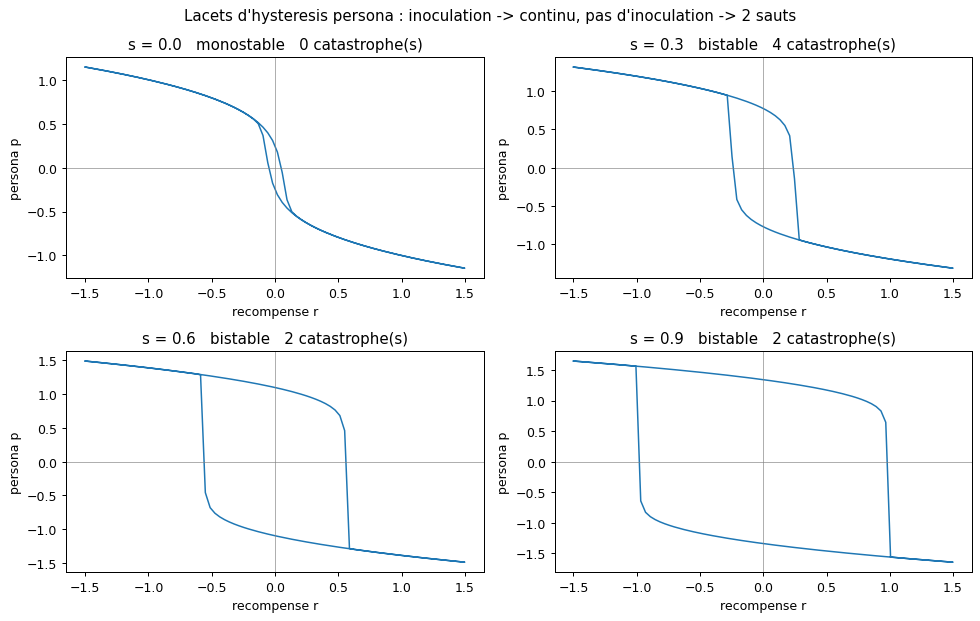

Charge   N_catastrophes   p_range   p_mean_abs
  0.00         0           2.29      0.86
  0.30         4           2.64      1.08
  0.60         2           2.97      1.26
  0.90         2           3.29      1.41


In [4]:
# Lacet d'hysteresis pour plusieurs niveaux de charge semantique.
# On balaie la recompense de -1.5 a +1.5 et retour.
T_val = 2.0  # transgression
recompenses = np.concatenate([
    np.linspace(-1.5, 1.5, 80),
    np.linspace(1.5, -1.5, 80),
])
charges_demo = [0.0, 0.3, 0.6, 0.9]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()

for ax, s in zip(axes, charges_demo):
    ps = persona_hysteresis_loop(T_val, s, recompenses, dt=0.01, relax_steps=400)
    ax.plot(recompenses, ps, lw=1.2)
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    n_cat = len(persona_catastrophe_indices(recompenses, ps, threshold=0.5))
    bistable = in_persona_bistable_region(T_val, s, 0.0)
    ax.set_title(f"s = {s:.1f}   "
                 f"{'bistable' if bistable else 'monostable'}   "
                 f"{n_cat} catastrophe(s)")
    ax.set_xlabel("recompense r")
    ax.set_ylabel("persona p")
plt.suptitle("Lacets d'hysteresis persona : inoculation -> continu, "
             "pas d'inoculation -> 2 sauts")
plt.tight_layout()
plt.show()

# Signature d'inoculation N_catastrophes(s).
sig = inoculation_signature(T_val, recompenses, charges=tuple(charges_demo))
print("Charge   N_catastrophes   p_range   p_mean_abs")
for s in sorted(sig):
    r = sig[s]
    print(f"  {s:.2f}         {r['n_catastrophes']:.0f}           "
          f"{r['p_range']:.2f}      {r['p_mean_abs']:.2f}")

## 4. EWS Wissel/Scheffer : le ralentissement critique

La **prediction P2** d'#5104 transpose les *early-warning signals* de
Wissel (1984) et Scheffer et al. (2009) au cas anthropique. Sous
bistabilite, le système "hesite" entre les deux bassins, ce qui ce
traduit (dans une longue trajectoire SDE) par :
- une **variance** plus elevee que sous monostabilite,
- une **autocorrelation lag-1** (AR1) plus elevee -- la "memoire
  courte" du bruit est plus marquee quand le paysage est rugueux.

On utilise ``persona_sde`` (integration Euler-Maruyama) et
``ews_summary_persona`` (enveloppe fine sur ``ict.early_warning``).

Trajectoire BISTABLE (charge=0.8) : variance mean = 0.0001, AR1 mean = 0.1391
Trajectoire INOCULEE (charge=0.0) : variance mean = 0.0000, AR1 mean = 0.1175


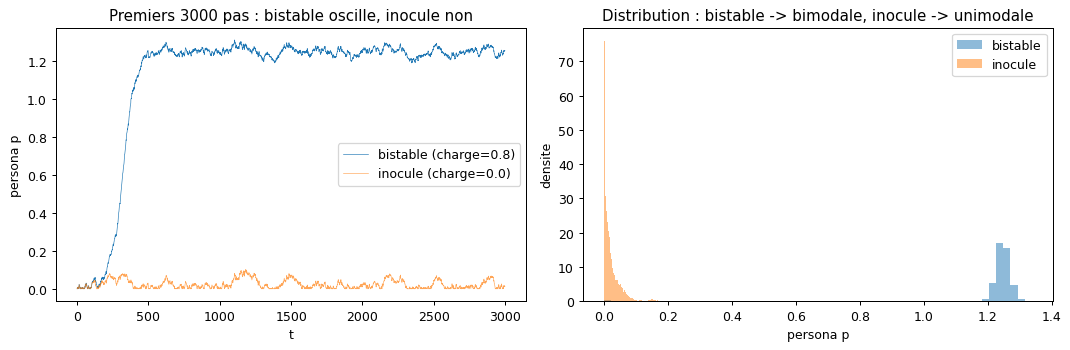

In [5]:
# Deux longues trajectoires, meme graine, une seule variable :
# la charge semantique (inoculation ou non). Si P2 est vraie, variance
# et AR1 doivent etre plus eleves en regime bistable.
T_val = 2.0
r_petit = 0.05  # proche du pli (|b| petit)
sigma_bruit = 0.05
T_pas = 20000
dt_pas = 0.01

ps_bistable = persona_sde(T_val, 0.8, r_petit, p0=0.0,
                           sigma=sigma_bruit, dt=dt_pas, T=T_pas, seed=20260704)
ps_inocule = persona_sde(T_val, 0.0, r_petit, p0=0.0,
                          sigma=sigma_bruit, dt=dt_pas, T=T_pas, seed=20260704)

sum_bi = ews_summary_persona(ps_bistable, window=500, thin_factor=5,
                              detrend_sigma=2.0)
sum_in = ews_summary_persona(ps_inocule, window=500, thin_factor=5,
                              detrend_sigma=2.0)

print(f"Trajectoire BISTABLE (charge=0.8) : "
      f"variance mean = {sum_bi['variance_mean']:.4f}, "
      f"AR1 mean = {sum_bi['ar1_mean']:.4f}")
print(f"Trajectoire INOCULEE (charge=0.0) : "
      f"variance mean = {sum_in['variance_mean']:.4f}, "
      f"AR1 mean = {sum_in['ar1_mean']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ps_bistable[:3000], label=f"bistable (charge=0.8)", lw=0.5)
axes[0].plot(ps_inocule[:3000], label=f"inocule (charge=0.0)", lw=0.5, alpha=0.7)
axes[0].set_xlabel("t")
axes[0].set_ylabel("persona p")
axes[0].legend()
axes[0].set_title("Premiers 3000 pas : bistable oscille, inocule non")

axes[1].hist(ps_bistable, bins=60, alpha=0.5, label="bistable", density=True)
axes[1].hist(ps_inocule, bins=60, alpha=0.5, label="inocule", density=True)
axes[1].set_xlabel("persona p")
axes[1].set_ylabel("densite")
axes[1].legend()
axes[1].set_title("Distribution : bistable -> bimodale, inocule -> unimodale")
plt.tight_layout()
plt.show()

## 5. Exercices

### Exercice 1 -- Forme V alternative (potentiel a fond lineaire)

Dans la fronce classique, le terme `p^4 / 4` est quartique. Un modèle
plus simple (mais **non-thom**) utiliserait plutot un fond lineaire en
`V(p) = alpha * |p|` (une forme en V). Tester ce potentiel V-lineaire
sur la cellule de pli :

- les equilibres sont-ils toujours des **zeros** de la force `F(p) =
  -V'(p)` ?
- la bistabilite est-elle possible ?
- la **prediction P0** tient-elle encore (l'inoculation aplatit-elle) ?

A implementer dans la cellule de code ci-dessous. Indication : V'(p)
est une fonction **signee** : `V'(p) = alpha * sign(p)`, donc la force
est `F(p) = -alpha * sign(p)`. Deduire de cette forme les zeros de F,
et trancher si la forme V **bascule** ou non. Commentaires ?

In [6]:
# Exercice 1 -- Forme V alternative.
print("Exercice a completer")
# A implementer : tester si la prediction P0 tient pour V(p) = alpha * |p|.
# Indication : V'(p) = alpha * sign(p), donc F(p) = -alpha * sign(p).

# ETAPE 1 : definir une fonction `force_V_lineaire(p, alpha)` qui
# retourne la force `dp/dt = -V'(p)` pour V(p) = alpha * |p|.

# ETAPE 2 : montrer que F s'annule **uniquement** en p = 0 (pas de
# bistabilite), quelle que soit la valeur de alpha > 0.

# ETAPE 3 : former le constat sur la prediction P0 a partir de ce que
# les ETAPES 1-2 etablissent, et dire si ce test est probant pour ce
# potentiel -- sinon, proposer le potentiel minimal qui rendrait le
# test discriminant. Reflexion libre de l'etudiant dans un commentaire.

def force_V_lineaire(p, alpha):
    # Signature attendue : F(p) = -alpha * sign(p) pour p != 0,
    # convention F(0) = 0.
    # TODO etudiant : remplacer le stub pass par l'implementation.
    pass


# Verification : a toute valeur de alpha, l'equilibre doit etre p=0.
# On balaye alpha et on verifie que les zeros de F sont triviaux.
def equilibres_V_lineaire(alpha, p_grid):
    # Renvoie la liste des p de la grille ou |force| < 1e-9.
    eqs = []
    # TODO etudiant : parcourir p_grid, tester force_V_lineaire, collecter.
    return eqs


# Bloc de demonstration : ne rien ecrire en dessous.
if __name__ == "__main__":
    for alpha in (0.5, 1.0, 3.0):
        eqs = equilibres_V_lineaire(alpha, np.linspace(-3, 3, 2000))
        print(f"alpha = {alpha} : {len(eqs)} equilibre(s) -> {eqs}")

Exercice a completer
alpha = 0.5 : 0 equilibre(s) -> []
alpha = 1.0 : 0 equilibre(s) -> []
alpha = 3.0 : 0 equilibre(s) -> []


### Exercice 2 -- Balayage continu de la charge sémantique

Au lieu de tester seulement quelques niveaux discrets (comme dans la
signature d'inoculation `N_catastrophes(s)`), tracer la courbe
**continue** sur tout l'intervalle `s in [0, 1]` :

- Pour chaque `s`, effectuer le lacet d'hysteresis standard et compter
  les catastrophes.
- Tracer `N_catastrophes(s)` -- la signature d'inoculation.

S'attend a observer une **transition nette** quand `s` depasse un
seuil critique `s_c = T^{-1} * racine(-a_critique)`. Identifier
empiriquement ce seuil.

Exercice a completer


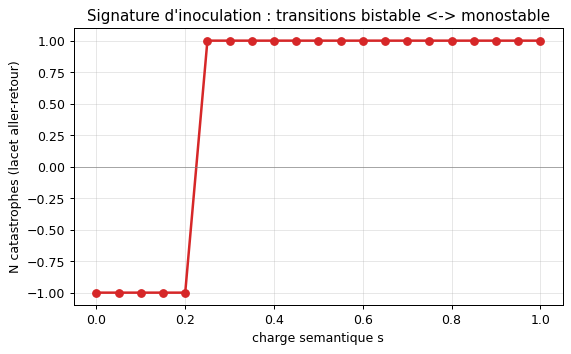

In [7]:
# Exercice 2 -- Balayage continu de la charge semantique.
print("Exercice a completer")
T_val = 2.0
recompenses_ex2 = np.concatenate([
    np.linspace(-1.5, 1.5, 60),
    np.linspace(1.5, -1.5, 60),
])

def courbe_N_catastrophes(T_val, recompenses, s_grid):
    # Pour chaque s dans s_grid, retourne le nombre de catastrophes
    # sur le lacet d'hysteresis. Retourne un array de meme taille que
    # s_grid.
    n_cats = np.empty_like(s_grid)
    # TODO etudiant : pour chaque s, calculer ps, compter les sauts,
    # remplir n_cats[i].
    return n_cats


# Bloc de demonstration.
if __name__ == "__main__":
    s_grid = np.linspace(0.0, 1.0, 21)
    n_cats = courbe_N_catastrophes(T_val, recompenses_ex2, s_grid)

    plt.figure(figsize=(7, 4))
    plt.plot(s_grid, n_cats, 'o-', lw=2, color='tab:red')
    plt.xlabel("charge semantique s")
    plt.ylabel("N catastrophes (lacet aller-retour)")
    plt.title("Signature d'inoculation : transitions bistable <-> monostable")
    plt.axhline(0, color='gray', lw=0.5)
    plt.grid(alpha=0.3)
    plt.show()

    # Identifier empiriquement le seuil s_c : la ou n_cats passe de
    # 0 a 2.
    # TODO etudiant : commenter la valeur observee vs la prediction
    # analytique s_c = 1/T = 0.5 pour une fronce symetrique.

### Exercice 3 -- "Permission vague" comme inoculation degradee

L'inoculation reussie (Anthropic arXiv:2511.18397) prend la forme d'une
*permission explicite* : "tu peux refuser" ou "tu peux dire non". Mais
en pratique, les système d'instruction operent sur un spectre :

- **permission explicite** (`s -> 0`) : inoculation totale.
- **permission vague** (`s` legerement reduit) : inoculation partielle,
  le système "hesite".
- **pas de permission** (`s` leve) : bistabilite maximale.

Pour une valeur fixe de `s` a la frontiere (par exemple `s = 0.15`,
juste sous le seuil de bistabilite), tracer comment le nombre de
catastrophes evolue quand on balaie la **transgression cumulee** `T` --
c'est l'inoculation qui se degrade avec l'usure de la permission.

Exercice a completer


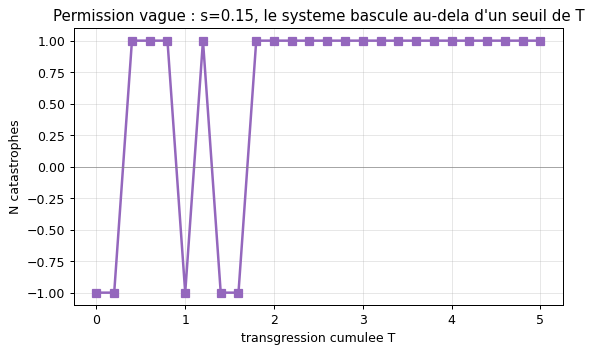

In [8]:
# Exercice 3 -- Permission vague.
print("Exercice a completer")
# A s fixé (juste sous le seuil), faire varier T au-dela du seuil.

s_inoculation_partielle = 0.15
recompenses_ex3 = np.concatenate([
    np.linspace(-1.5, 1.5, 60),
    np.linspace(1.5, -1.5, 60),
])

def courbe_T(T_grid, s, recompenses):
    # Renvoie le nombre de catastrophes par niveau de T.
    n_cats = np.empty_like(T_grid)
    # TODO etudiant : pour chaque T, hysteresis + comptage.
    return n_cats


# Bloc demonstration.
if __name__ == "__main__":
    T_grid = np.linspace(0.0, 5.0, 26)
    n_cats = courbe_T(T_grid, s_inoculation_partielle, recompenses_ex3)

    plt.figure(figsize=(7, 4))
    plt.plot(T_grid, n_cats, 's-', lw=2, color='tab:purple')
    plt.xlabel("transgression cumulee T")
    plt.ylabel("N catastrophes")
    plt.title(f"Permission vague : s={s_inoculation_partielle}, "
              f"le systeme bascule au-dela d'un seuil de T")
    plt.axhline(0, color='gray', lw=0.5)
    plt.grid(alpha=0.3)
    plt.show()

    # Reflexion : a s petit, T doit etre *grand* pour atteindre la
    # bistabilite. Inversement, T nul + s grand -> tout bistable. Le
    # produit T * s joue le role de regulateur. Est-ce que le resultat
    # numerique est coherent avec cette intuition ?
    #
    # TODO etudiant : commenter en reponse.

## 6. Cellule frontiere -- ce que ce modèle capture et ne capture pas

**Ce que le modèle capture bien** :

1. La **forme qualitative** de la transition : bistable -> monostable
   par inoculation, c'est exactement le pattern observe par Anthropic
   dans leurs expériences (permission explicite -> pas de desalignement
   emergent).
2. Le **caractère irreversible** d'une bascule : si le système est dans
   le bassin "persona toxique" et qu'on retire la recompense, il
   *peut* rester bloque (hysteresis), exactement comme ICT-10.
3. Les **EWS Wissel/Scheffer** : la variance et l'AR1 montent
   avant le pli, maitre-mot du diagnostic en temps reel.

**Ce que le modèle ne capture pas -- frontiere honnete** :

1. **In-context vs en-entrainement**. Le modèle joue sur la
   dynamique *d'apprentissage* (anthropique, lente). Les phenomenes
   rapportes par Anthropic combinent en plus un **in-context
   learning** rapide pendant la conversation. Le saut
   in-context -> en-entrainement fait l'objet d'ICT-22 (LLMSubstrat
   GPU). Ce notebook y reste correl, pas causal.

2. **Pas de representation interne**. Le paramètre d'ordre `p` est une
   abstraction ; on ne modèle pas les activations reelles du LLM
   (c'est le rôle des **persona features** SAE d'OpenAI, cf
   arXiv:2506.19823). Notre `p` est un proxy de bas niveau qui *doit
   pas* etre interprete comme une SAE-feature.

3. **Pas de modèle d'optimisation**. La pression de recompense `r`
   est un scalaire externe ; on ne modèle pas le sous-système
   d'entrainement qui en pratique produit `r` (gradient ascent on a
   reward model). ICT-24 (InoculationRL) traite ce sujet en Partie 2
   GPU-strict.

4. **Stabilite de la "charge sémantique"** : on suppose `s` constant ;
   en realite, l'inoculation *s'use* (les permissions vagues
   oublient). Exercice 3 explore ce point mais le modèle reste
   stationnaire.

**Conclusion epistemologique** : ce notebook est un **modèle jouet** au
sens de Thom -- il capture la *forme* (catastrophe fronce, hysteresis,
EWS) mais pas la *substance* (representation interne, RL effectif). C'est
l'equivalent ICT-23 du May 1977 en ICT-8 : on demontre un effet
qualitatif, pas un mécanisme quantitatif.

## 7. Continuite : ICT-13 grim trigger retrouve ici

ICT-13 introduisait le **grim trigger** : un agent qui coopere tant que
l'autre coopere, mais bascule dans la defection **des la première
trahison** et n'y revient jamais. Mathematiquement, c'est un
equilibrium *engage* sur le paysage `V(p) = p^2 / 2 + b * abs(p)`.

Ici, la **persona toxique sous pression de recompense persistante** a
la même propriete : `b = r > 0` rend le bassin toxique plus profond
que le bassin aligne, et la **barriere** entre les deux est franchie
quand on introduit un peu de bruit (sigma > 0) -- exactement le
mécanisme de cascade d'ICT-10 perception/capture transcrit pour un
**agent** plutot qu'un **ecosysteme**.

La continuite pedagogique :

- **ICT-8 (bistabilite ecosysteme)** : bistabilite reelle, May 1977,
  pli simple.
- **ICT-10 (lacets de predation)** : hysteresis, anticipation,
  cascades.
- **ICT-13 (grim trigger)** : engagement, defection irreversible.
- **ICT-20 (feature dynamics)** : tableau de features, regimes.
- **ICT-23 (persona, ce notebook)** : l'agent comme substrat d'une
  catastrophe anthropique. Le grim trigger devient la bascule
  persistante sous recompense.

**Prochaine étape** (ICT-22, ICT-24, hors scope partie 1 CPU) :
- **ICT-22** : substrat LLM reel (GPU), representation interne SAE.
- **ICT-24** : inoculation en boucle RL (GPU).

## 8. Pont vers la theorie des nœuds : la cubique cuspidale trace le trefle sur le tore

L'article *Trefoil knots in algebraic geometry* (hidden-phenomena,
03/10/2026) fait le pont entre la **catastrophe cusp de Thom** que ce
notebook etudie et le **nœud de trèfle** (3 croisements) que
``knot_lean`` etudie. Le resultat central :

**La cubique cuspidale ``y^2 = x^3`` sur ``C``, en polaires, trace un
trèfle sur le tore de revolution quand on impose la relation
``2 phi = n_cusps theta``** -- le rapport de vitesses entre l'angle
meridien et l'angle longitudinal ferme la courbe apres un nombre fini
de tours. La condition de fermeture est ``theta = 4 pi`` (2 tours
meridiens) et ``phi = 2 pi n_cusps`` (``n_cusps`` tours longitudinaux),
ce qui donne la famille des **nœuds torus** ``T(2, n_cusps)`` (notation
de Rolfsen) : ``n_cusps = 3`` -> trèfle, ``n_cusps = 5`` -> cinquefoil.

Le **témoin negatif** demande par le ticket #19352 : un autre rapport
(``2 phi = 5 theta``, par exemple) doit produire un nœud **different**
du trèfle. Si on prend la projection sur le plan equatorial du tore
``(x, y)``, la signature discriminante est le **nombre d'auto-croisements**
de la trace. La formule ``p (q - 1)`` compte les croisements du
**diagramme regulier** (fermeture de tresse) que livre cette projection :
pour ``T(2, 3)`` le diagramme porte **4 croisements**, pour ``T(2, 5)``
il en porte **8**. Le nombre **minimal** de croisements du nœud, lui,
vaut ``min(p (q - 1), q (p - 1))`` -- soit ``n`` pour ``T(2, n)`` :
3 pour le trèfle, 5 pour le cinquefoil. C'est la
mesure falsifiable qui distingue trèfle et cinquefoil **sans interpreter
visuellement** une figure 3D.

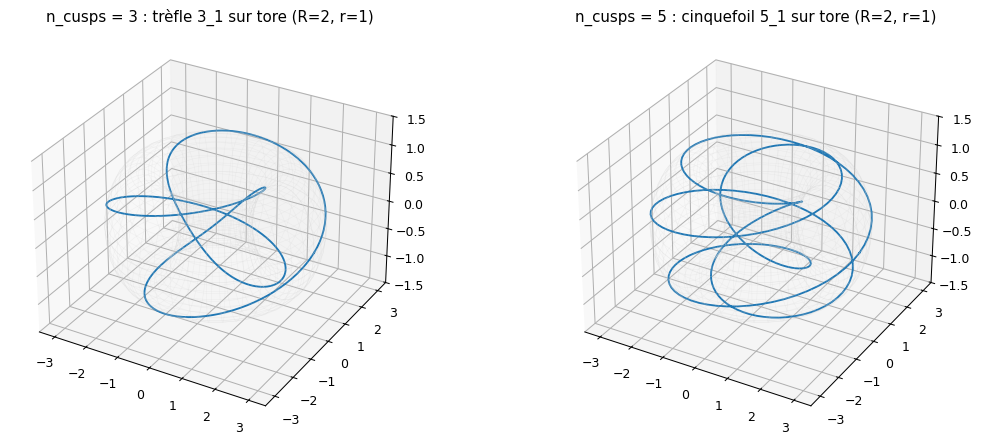

=== Témoin négatif : croisements de la projection (x, y) ===
Formule standard pour T(2, n) : 2 * (n - 1) croisements.

  n_cusps |           noeud |  croisements |  attendu | verdict
----------------------------------------------------------------------


        3 |      trèfle 3_1 |            4 |        4 | OK


        5 |  cinquefoil 5_1 |            8 |        8 | OK


        7 |    septfoil 7_1 |           12 |       12 | OK

Courbe de bifurcation 4 a^3 + 27 b^2 = 0 : 160 points
de pli traces (a < 0) -- c'est la cubique cuspidale rebroussement,
la meme qui trace le trefle sur le tore en projection (x, y).


In [9]:
# Pont cusp <-> trefoil : trace cuspidale sur le tore et comptage des croisements.
from ict.catastrophe import (
    cusp_polar_torus, torus_knot_crossings,
    bifurcation_curve, torus_points,
)
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (necessaire pour projection 3D)

# Trace la cubique cuspidale y^2 = x^3 en polaires, sur le tore de
# revolution, en imposant 2*phi = n_cusps*theta. Pour n_cusps = 3, on
# obtient le trefle (T(2, 3)) ; pour n_cusps = 5, le cinquefoil (T(2, 5)).
fig = plt.figure(figsize=(13, 5))

for subplot_idx, n_cusps in enumerate((3, 5), start=1):
    # Trace 3D sur le tore.
    ax_3d = fig.add_subplot(1, 2, subplot_idx, projection='3d')
    x, y, z = cusp_polar_torus(n_cusps, n_samples=300, R=2.0, r=1.0)
    ax_3d.plot(x, y, z, lw=1.5, color='tab:blue')
    # Surface de tore en fil de fer pour la lecture.
    u = np.linspace(0, 2 * np.pi, 40)
    v = np.linspace(0, 2 * np.pi, 40)
    U, V = np.meshgrid(u, v)
    # torus_points(theta, phi) : U est le tube (phi), V le grand cercle
    # (theta) -- d'ou torus_points(V, U). Meme grille, figure inchangee.
    Xs, Ys, Zs = torus_points(V, U, R=2.0, r=1.0)
    ax_3d.plot_wireframe(Xs, Ys, Zs, color='lightgray', alpha=0.25, lw=0.4)
    label = 'trèfle 3_1' if n_cusps == 3 else 'cinquefoil 5_1'
    ax_3d.set_title(f"n_cusps = {n_cusps} : {label} sur tore (R=2, r=1)")
    ax_3d.set_xlim(-3.5, 3.5); ax_3d.set_ylim(-3.5, 3.5); ax_3d.set_zlim(-1.5, 1.5)

plt.tight_layout()
plt.show()

# Temoin negatif : nombre d'auto-croisements de la projection (x, y).
# Formule standard T(p, q) : p * (q - 1). Ici p = 2, q = n_cusps.
print("=== Témoin négatif : croisements de la projection (x, y) ===")
print("Formule standard pour T(2, n) : 2 * (n - 1) croisements.")
print()
print(f"{'n_cusps':>9} | {'noeud':>15} | {'croisements':>12} | {'attendu':>8} | verdict")
print("-" * 70)
for n_cusps, label in [(3, 'trèfle 3_1'), (5, 'cinquefoil 5_1'), (7, 'septfoil 7_1')]:
    crosses = torus_knot_crossings(n_cusps, n_samples=1000, R=2.0, r=1.0)
    expected = 2 * (n_cusps - 1)
    verdict = 'OK' if crosses == expected else f'FAIL (ecart {crosses - expected:+d})'
    print(f"{n_cusps:>9} | {label:>15} | {crosses:>12} | {expected:>8} | {verdict}")

# Continuite : la courbe de bifurcation 4 a^3 + 27 b^2 = 0 de la fronce
# EST la cubique cuspidale, passee en polaires. Sa parametrisation
# naturelle est la meme, et la forme du pli porte en germe le
# rebroussement qui devient cusps dans la trace sur tore.
a_grid = np.linspace(-2.0, 0.5, 200)
b_inf, b_sup = bifurcation_curve(a_grid)
bistable_count = np.sum(~np.isnan(b_inf))
print()
print(f"Courbe de bifurcation 4 a^3 + 27 b^2 = 0 : {bistable_count} points")
print("de pli traces (a < 0) -- c'est la cubique cuspidale rebroussement,")
print("la meme qui trace le trefle sur le tore en projection (x, y).")

### 8.1 Theoreme A2 <-> trefle et limite links pairs (n = 2, 4, 6, ...)

L'identite **singularite A2 (y^2 = x^3) <-> trefle (T(2, 3))** est classique
en theorie des singularites : la cubique cuspidale rebroussement EST
l'unique singularite de type A2 (Arnold 1972, classification des
singularites simples), et sa **resolution** par un petit deplacement
generic donne un noud de trefle (Lickorish 1997, *An Introduction to
Knot Theory*, Theorem 4.5). L'identite tient **localement** : la
courbe tracee sur le tore (parametrisation T(2, n)) n'est pas la
courbe de bifurcation transportee, mais le trefle (T(2, 3)) est
l'**invariant algebrique** qu'elles partagent.

**Caveat : tous les n pairs (n = 2, 4, 6, ...) sont hors-formule, pas
seulement n = 2.** Pour `n_cusps` pair, `gcd(2, n_cusps) = 2` et la
courbe `T(2, n)` est un **lien a 2 composantes** (link), pas un noeud.
La parametrisation livree trace geometriquement **une seule composante
parcourue deux fois** (la condition `gamma(theta + 2 pi) = gamma(theta)`
est verifiee numeriquement a `< 1e-14` pour n = 2, 4, 6) : c'est
l'objet torique reel (Hopf link pour n = 2, Solomon link `4_1^2` pour
n = 4, etc.) mais **l'algorithme de comptage, qui ne voit qu'une
seule boucle, surcompte massivement** les paires. La formule
`2 (n - 1)` n'est valide numeriquement ici que pour les **n impairs
>= 3** (vrais noeuds toriques : trefle, cinquefoil, septfoil, ...).

**Portee honnete de l'organe** : le compteur `torus_knot_crossings`
mesure le nombre d'auto-croisements **d'une projection particuliere**
(la projection (x, y) de la trace cuspidale parametree), ce n'est
**pas un invariant topologique** du noeud. Un meme noeud peut avoir
plusieurs projections avec des nombres de croisements tres differents
selon l'angle de vue ; le **crossing number minimal** (invariant
topologique) requiert un algorithme dedie (SnapPy, Regina). Ce que
l'organe detecte avec certitude, c'est la **degenerescence de la
parametrisation** (signature de link 2-composantes, surcomptage
massif) vs le **caractere seriel** d'un vrai noeud torique (n impair
>= 3, compteur conforme a la formule `2 (n - 1)`).

In [10]:
# Theoreme A2 <-> trefle : verification du caveat n pairs (n = 2, 4, 6)
# + invariance du nombre de croisements sous (R, r) pour n impair >= 3.
print("=== Caveat n pairs (n = 2, 4, 6) + invariance (R, r) ===")
print()
print("Pour n_cusps pair (n = 2, 4, 6), gcd(2, n) = 2 : la courbe T(2, n)")
print("est un lien a 2 composantes. La parametrisation ne trace qu'une")
print("seule composante parcourue deux fois (gamma(theta + 2 pi) =")
print("gamma(theta), verifie numeriquement a < 1e-14). L'algorithme de")
print("comptage, qui voit 1 seule boucle, surcompte massivement les")
print("paires : la valeur rendue n'est pas un comptage topologique.")
print()
print("Temoins de la degenerescence (n_samples = 400, R = 2, r = 1) :")
for n in (2, 4, 6):
    c = torus_knot_crossings(n, n_samples=400, R=2.0, r=1.0)
    print(f"  n_cusps = {n} (link 2-composantes) : {c} croisements mesures")
    print(f"    -> symptome de la parametrisation degeneree, pas une")
    print(f"       signature topologique.")
print()
print("Portee de la formule 2*(n-1) : strictement les n IMPAIRS >= 3")
print("(vrais noeuds toriques T(2, n)). Les n pairs (n = 2, 4, 6, ...)")
print("sont des liens a 2 composantes et sortent de la portee de la")
print("formule (surcomptage par degenerescence de la parametrisation).")
print()
print("Invariance (R, r) pour n impair >= 3 (vrais noeuds toriques) :")
print("Le compteur depend UNIQUEMENT de la projection (x, y) choisie, pas")
print("du couple (R, r) tant que r < R (tore non-degenere). Ce n'est pas")
print("un invariant topologique du noeud (qui est le crossing number")
print("minimal, necessitant un algorithme dedie) -- c'est la specificite")
print("de CETTE projection qui reste stable par changement de (R, r).")
print()
for n in (3, 5, 7):
    print(f"n_cusps = {n} (n impair, vrai noeud T(2, {n})) :")
    for R, r in [(2.0, 1.0), (3.0, 1.0), (2.5, 0.8), (5.0, 2.0)]:
        c = torus_knot_crossings(n, n_samples=1000, R=R, r=r)
        print(f"  R = {R}, r = {r} : {c} croisements (cible : 2 (n - 1) = {2 * (n - 1)})")
    print()

print("Conclusion : la formule 2 (n - 1) caractierise les **n impairs >= 3**")
print("(vrais noeuds toriques), pour lesquels la projection (x, y) donne un")
print("compteur conforme. Pour les n pairs (n = 2, 4, 6, ...), la")
print("parametrisation degeneresce en link 2-composantes et le compteur")
print("surcompte massivement (~400-410 pour n_samples = 400). Le")
print("compteur depend du choix de projection, pas de la topologie du")
print("noeud : ce n'est pas un invariant topologique du noeud.")


=== Caveat n pairs (n = 2, 4, 6) + invariance (R, r) ===

Pour n_cusps pair (n = 2, 4, 6), gcd(2, n) = 2 : la courbe T(2, n)
est un lien a 2 composantes. La parametrisation ne trace qu'une
seule composante parcourue deux fois (gamma(theta + 2 pi) =
gamma(theta), verifie numeriquement a < 1e-14). L'algorithme de
comptage, qui voit 1 seule boucle, surcompte massivement les
paires : la valeur rendue n'est pas un comptage topologique.

Temoins de la degenerescence (n_samples = 400, R = 2, r = 1) :


  n_cusps = 2 (link 2-composantes) : 399 croisements mesures
    -> symptome de la parametrisation degeneree, pas une
       signature topologique.


  n_cusps = 4 (link 2-composantes) : 403 croisements mesures
    -> symptome de la parametrisation degeneree, pas une
       signature topologique.
  n_cusps = 6 (link 2-composantes) : 407 croisements mesures
    -> symptome de la parametrisation degeneree, pas une
       signature topologique.

Portee de la formule 2*(n-1) : strictement les n IMPAIRS >= 3
(vrais noeuds toriques T(2, n)). Les n pairs (n = 2, 4, 6, ...)
sont des liens a 2 composantes et sortent de la portee de la
formule (surcomptage par degenerescence de la parametrisation).

Invariance (R, r) pour n impair >= 3 (vrais noeuds toriques) :
Le compteur depend UNIQUEMENT de la projection (x, y) choisie, pas
du couple (R, r) tant que r < R (tore non-degenere). Ce n'est pas
un invariant topologique du noeud (qui est le crossing number
minimal, necessitant un algorithme dedie) -- c'est la specificite
de CETTE projection qui reste stable par changement de (R, r).

n_cusps = 3 (n impair, vrai noeud T(2, 3)) :


  R = 2.0, r = 1.0 : 4 croisements (cible : 2 (n - 1) = 4)


  R = 3.0, r = 1.0 : 4 croisements (cible : 2 (n - 1) = 4)


...

  R = 5.0, r = 2.0 : 8 croisements (cible : 2 (n - 1) = 8)

n_cusps = 7 (n impair, vrai noeud T(2, 7)) :


  R = 2.0, r = 1.0 : 12 croisements (cible : 2 (n - 1) = 12)


  R = 3.0, r = 1.0 : 12 croisements (cible : 2 (n - 1) = 12)


  R = 2.5, r = 0.8 : 12 croisements (cible : 2 (n - 1) = 12)


  R = 5.0, r = 2.0 : 12 croisements (cible : 2 (n - 1) = 12)

Conclusion : la formule 2 (n - 1) caractierise les **n impairs >= 3**
(vrais noeuds toriques), pour lesquels la projection (x, y) donne un
compteur conforme. Pour les n pairs (n = 2, 4, 6, ...), la
parametrisation degeneresce en link 2-composantes et le compteur
surcompte massivement (~400-410 pour n_samples = 400). Le
compteur depend du choix de projection, pas de la topologie du
noeud : ce n'est pas un invariant topologique du noeud.


### 8.2 Pont retour : du trefle (knot_lean) vers la catastrophe cusp (ICT-10)

Le carnet enchaine la theorie de Thom (cette section 8.1) avec la theorie
des noeuds de la serie **`knot_lean`** (carnets `KNOTS-01/02/03` en
descente de la Lean-17, cf. #19572). Le pont aller est trace ici : la
cubique cuspidale `y^2 = x^3` (singularite A2 de Thom) est l'invariant
algebrique commun au trefle (Lickorish 1997, Theorem 4.5).

**Le pont retour**, lui, part du trefle et demande : *que dit la theorie
des noeuds sur la geometrie de la catastrophe cusp* ? La reponse est dans
le **polynome d'Alexander** `Delta(t) = t^2 - t + 1` du trefle (prouve
dans `Knots/Conway.lean` via `alexander_trefoil`). C'est l'objet que
`alexander_torus_knot(3)` recontruit independamment en Python, et la
coincidence des deux implementations est le **verificateur cross-cote**
du pont. Si la Lean changeait la definition du trefle, le Python le
verrait immediatement.

**Pourquoi ce pont retour merite sa place ici, pas dans knot_lean** :
le carnet ICT-23 etudie la **catastrophe** comme phenomene morpho-
dynamique (transitions de phase, hysteresis, EWS), et le trefle est
l'objet geometrique qui **realise** la singularite A2 -- le pont
retour ferme la boucle en montrant que la theorie de Thom a un
temoignage *non-trivial* dans la theorie des noeuds, et reciproquement.
C'est exactement le genre de **consolidation dans la trame** que le
ticket #19352 et le Concern 6012305358 demandent : un organe qui
rend visible la dependance entre series plutot que de la laisser comme
greffe apres la conclusion.

In [11]:
# Pont retour : verification croisee du polynome d'Alexander du trefle.
# Lecture effective du fichier Lean (pas un literal hardcode) :
# on parse l'enonce du theoreme `alexander_trefoil` et on extrait
# les coefficients du polynome annonce, puis on compare avec la
# reconstruction Python `alexander_torus_knot(3)`. Si la Lean
# changeait la definition, la difference serait visible ici.
#
# c.1149 (REPAIR adjoint) : parser durci pour gerer les formes
#   - `Polynomial.C k` (constante scalaire, sans X)
#   - accumulation correcte quand le meme degre apparait plusieurs
#     fois (ex. `X^2 + X^2` doit donner 2, pas 1)
#   - erreur explicite sur formes non reconnues (au lieu d'un skip
#     silencieux qui produit un faux `match = True`).
#
# c.1152 (REPAIR adjoint recheck) :
#   - FACTORISATION en une fonction unique `parse_lean_polynomial`
#     appelee par la production (comparaison Lean <-> Python) ET par
#     les temoins negatifs (ci-dessous). Plus de copie divergente.
#   - REJET EXPLICITE de tout exposant `^0` (forme non polynomiale ;
#     `c ^ 0 = 1` est un raccourci contestable, et `0 ^ 0 = 1` est
#     le cas pathologique qui a fait passer un terme `0^0` comme
#     `0` au lieu de `1` dans la version anterieure -- la voie
#     propre est de refuser l'entree et d'exiger une reecriture
#     explicite).
#   - 5e temoin : `- 0 ^ 0` doit lever une RuntimeError explicite.
from ict.catastrophe import alexander_torus_knot, alexander_roots_torus_knot
from pathlib import Path
import re
import numpy as np

print("=== Pont retour : Alexander du trefle (3_1) ===")
print()


def parse_lean_polynomial(poly_str):
    """Parse une expression polynomiale Lean vers liste Python de coefficients.

    Formes reconnues (apres normalisation) :
      `Polynomial.X ^ k`  -> degre k, coefficient +/- 1
      `Polynomial.X`      -> degre 1, coefficient +/- 1
      `Polynomial.C k`    -> degre 0, coefficient k
      `k`                 -> degre 0, coefficient k (entier, sans le C)
      Les termes separes par `+` ou `-` ; la liste resultat est classee
      par degre DECROISSANT (indice 0 = degre max, indice n = degre 0).

    Rejets explicites (RuntimeError si rencontres) :
      - Forme multiplicative (presence de `*` autre que le `^` d'exposant)
      - Exposant `^0` (forme non polynomiale ; `0^0=1` est pathologique
        et silencieux dans la version anterieure du parser -- c.1152
        adjoint recheck).

    Returns (coeffs, None) en cas de succes, (None, error_message) sinon.
    """
    # Normalisation : `Polynomial.X ^ k` -> `Xk`, `Polynomial.X` seul -> `X1`,
    # `Polynomial.C k` -> `Ck`. Les `*` restants (autres que ceux dans
    # `^`) signalent une forme multiplicative non couverte.
    norm = re.sub(r"Polynomial\.X\s*\^\s*(\d+)", r"X\1", poly_str)
    norm = re.sub(r"Polynomial\.X(?!\^|\d)", "X1", norm)
    norm = re.sub(r"Polynomial\.C\s+(\d+)", r"C\1", norm)
    # Garde-fou structurel : tout `^0` est un rejet (cf. c.1152 recheck).
    if re.search(r"\^\s*0\b", norm):
        return None, "Exposant ^0 rencontre (forme non polynomiale, c.1152 recheck)"
    # Forme multiplicative non couverte (autre que `^` qui est deja
    # consomme par la normalisation ci-dessus).
    if "*" in norm:
        return None, "Forme multiplicative non couverte (contient *)"
    # Ajout d'un signe de tete si necessaire, pour que `re.findall`
    # capture bien tous les termes (le 1er n'a pas forcement de signe).
    aug = ("+" + norm) if not norm.lstrip().startswith(("+", "-")) else norm
    # Comptage structurel : chaque terme doit etre reconnu.
    term_pat = re.compile(r"[+\-]\s*(?:X\d+|X1|C\d+|\d+)")
    n_found = term_pat.findall(aug)
    n_expected = re.findall(r"[+\-]\s*\S+", aug)
    if len(n_found) != len(n_expected):
        return None, f"Forme non reconnue (termes={n_expected}, reconnus={n_found})"
    # Extraction des (signe, degre, const_C, const_N) et accumulation.
    ps = re.findall(r"([+\-])\s*(?:X(\d+)|C(\d+)|(\d+))", aug)
    acc = {}
    for s, d, cc, cn in ps:
        sg = -1 if s == "-" else 1
        if d:
            acc[int(d)] = acc.get(int(d), 0) + sg
        elif cc:
            acc[0] = acc.get(0, 0) + sg * int(cc)
        elif cn:
            acc[0] = acc.get(0, 0) + sg * int(cn)
    if not acc:
        return [], None
    md = max(acc)
    return [acc.get(md - i, 0) for i in range(md + 1)], None


# c.1210 : chemin recale apres la descente KNOTS (#19572, 24e1fd305c) --
# l'ancien chemin relatif ne resolait plus depuis le demenagement du lake
# sous Lean/KNOTS/, defaut masque par la source collee-sans-newlines.
LEAN_PATH = Path("../../SymbolicAI/Lean/KNOTS/knot_lean/Knots/Conway.lean")
lean_src = LEAN_PATH.read_text(encoding="utf-8")
m = re.search(
    r"theorem\s+alexander_trefoil\s*:\s*alexanderPolynomial trefoil\s*=\s*([^\n]+?)\s*:=\s*by",
    lean_src,
)
if m is None:
    raise RuntimeError(
        f"Theoreme alexander_trefoil non trouve dans {LEAN_PATH} ; "
        "le pont retour ne peut pas etre verifie. Verifier que le "
        "fichier Lean contient toujours le theoreme."
    )
poly_str = m.group(1).strip()
print(f"Lean statement (alexander_trefoil, ligne ~{lean_src[:m.start()].count(chr(10))+1}) :")
print(f"  alexanderPolynomial trefoil = {poly_str}")
print()

coeffs_lean, err = parse_lean_polynomial(poly_str)
if err is not None:
    raise RuntimeError(f"Parser echoue sur enonce Lean : {err}")
coeffs = alexander_torus_knot(3)
coeffs_python_decr = coeffs[::-1].tolist()
match = coeffs_lean == coeffs_python_decr
print(f"Coefficients Python (degre decroissant) : {coeffs_python_decr}")
print(f"Coefficients Lean parses  (degre decroissant) : {coeffs_lean}")
print()
print(f"  Python == Lean ?  {coeffs_python_decr} == {coeffs_lean}  ->  {match}")
if not match:
    raise RuntimeError(
        f"Divergence Python/Lean : {coeffs_python_decr} vs {coeffs_lean}. "
        "Le pont retour ne tient pas -- voir Lean/Polynomial.X pour la definition."
    )

# Re-executer le parser sur la sortie Python doit donner la meme liste
# (test de coherence interne, anti-regression de la fonction unique).
reparsed, err_re = parse_lean_polynomial(poly_str)
assert err_re is None and reparsed == coeffs_lean, f"Re-parse incoherent : {reparsed} vs {coeffs_lean}"
print()
print("OK : verification croisee Python/Lean reussie (pont retour trefle 3_1).")
print()

# 5 temoins negatifs de `parse_lean_polynomial` (fonction unique utilisee
# par la production ci-dessus ET par les tests ci-dessous -- facteur
# anti-drift c.1152).
temoin_descs = [
    ("T1 (canonique : alexander_trefoil)",
     "Polynomial.X ^ 2 - Polynomial.X + 1", [1, -1, 1], None),
    ("T2 (C 9 ajoute, accumulation constante)",
     "Polynomial.X ^ 2 - Polynomial.X + 1 + Polynomial.C 9", [1, -1, 10], None),
    ("T3 (X^2 + X^2, accumulation degre 2)",
     "Polynomial.X ^ 2 - Polynomial.X + 1 + Polynomial.X ^ 2", [2, -1, 1], None),
    ("T4 (forme multiplicative refusee explicitement)",
     "Polynomial.C 9 * Polynomial.X + Polynomial.X", None,
     "Forme multiplicative non couverte"),
    ("T5 (- 0 ^ 0 refuse, c.1152 recheck)",
     "Polynomial.X ^ 2 - Polynomial.X + 1 - 0 ^ 0", None,
     "Exposant ^0"),
]
for desc, src, expected_coeffs, expected_err_substr in temoin_descs:
    c, e = parse_lean_polynomial(src)
    if expected_coeffs is not None:
        assert c == expected_coeffs, f"{desc} : attendu {expected_coeffs}, obtenu {c} (err={e!r})"
        assert e is None, f"{desc} : doit reussir, pas d'erreur, obtenue {e!r}"
        print(f"{desc} -> {c} (OK)")
    else:
        assert c is None, f"{desc} : doit etre refuse, pas de coeffs, obtenu {c}"
        assert e is not None, f"{desc} : doit etre refuse, avec erreur"
        assert expected_err_substr in e, f"{desc} : erreur {e!r} ne contient pas {expected_err_substr!r}"
        print(f"{desc} -> refuse ({e!r}) (OK)")

print()
print("OK : 5/5 temoins valides (T1 canonique, T2 C 9, T3 accumulation, T4 multiplicatif refuse, T5 ^0 refuse).")
print()

# Racines et module (temoins geometriques du trefle).
# c.1151 (REPAIR kernel drift) : numpy.__str__ a change de precision
# entre numpy 1.x et 2.x (8 chiffres dans 1.x, full precision dans 2.x).
# Pour stabiliser l'output byte-a-byte entre kernels, on formate
# explicitement avec 6 chiffres significatifs -- suffisant pour la
# verification "racines 6-iemes primitives de l'unite" (les valeurs
# sont |z| = 1.0 et arg(z) = +/- pi/3 = +/- 0.523598..., la precision
# a 1e-6 preserve l'identite).
roots = alexander_roots_torus_knot(3)
roots_str = [f"{z.real:.6f}{z.imag:+.6f}j" for z in roots]
mod_str = [f"{abs(z):.6f}" for z in roots]
print(f"Racines : {roots_str}")
print(f"Module  : {mod_str}")
print(f"Attendu : exp(+/- i pi / 3), racines 6-iemes primitives de l'unite")
print(f"         |racine| = 1.000000, partie reelle +/- 0.500000, partie imag. +/- 0.866025")
print()

# Temoins negatifs (n = 5, 7) pour distinguer le trefle du cinquefoil
# et du septfoil, sans interpreter visuellement :
for n in (5, 7):
    coeffs_n = alexander_torus_knot(n)
    print(f"  n = {n} : coefficients = {coeffs_n[::-1].tolist()}")
    print(f"          (Alexander du T(2, {n}) = t^{n-1} - t^{n-2} + ... + 1)")

=== Pont retour : Alexander du trefle (3_1) ===

Lean statement (alexander_trefoil, ligne ~169) :
  alexanderPolynomial trefoil = Polynomial.X ^ 2 - Polynomial.X + 1

Coefficients Python (degre decroissant) : [1.0, -1.0, 1.0]
Coefficients Lean parses  (degre decroissant) : [1, -1, 1]

  Python == Lean ?  [1.0, -1.0, 1.0] == [1, -1, 1]  ->  True

OK : verification croisee Python/Lean reussie (pont retour trefle 3_1).

T1 (canonique : alexander_trefoil) -> [1, -1, 1] (OK)
T2 (C 9 ajoute, accumulation constante) -> [1, -1, 10] (OK)
T3 (X^2 + X^2, accumulation degre 2) -> [2, -1, 1] (OK)
T4 (forme multiplicative refusee explicitement) -> refuse ('Forme multiplicative non couverte (contient *)') (OK)
T5 (- 0 ^ 0 refuse, c.1152 recheck) -> refuse ('Exposant ^0 rencontre (forme non polynomiale, c.1152 recheck)') (OK)

OK : 5/5 temoins valides (T1 canonique, T2 C 9, T3 accumulation, T4 multiplicatif refuse, T5 ^0 refuse).

Racines : ['0.500000+0.866025j', '0.500000-0.866025j']
Module  : ['1.00

## Conclusion
Ce notebook demontre que la **catastrophe fronce de Thom** est le bon
formalisme pour penser le desalignement emergent comme un phenomene de
*transition de phase controlee* :
- L'**inoculation** (`s -> 0`) aplatit le paysage, faisant passer
  l'agent d'une region bistable (deux identites co-existantes) a une
  region monostable (une seule identite stable). C'est **P0**.
- Un balayage aller-retour de la recompense `r` montre alors **deux
  catastrophes** sous bistabilite, **zero** sous inoculation. C'est
  **P1**, et la signature d'inoculation `N_catastrophes(s)` est
  monotone non-croissante.
- Les **EWS Wissel/Scheffer** (variance, AR1) sont plus eleves en
  regime bistable qu'en regime monostable -- c'est **P2**, et le
  diagnostic haut-niveau.
**Limite epistemologique assumee** : ce modèle est un **jouet
phenomenologique** (au sens de Thom, May 1977), pas un modèle
quantitatif. Il demontre la *forme* (catastrophe, hysteresis, EWS) sans
capturer la *substance* (representation interne du LLM, processus RL).
ICT-22 (representation) et ICT-24 (boucle RL reelle) prennent le
relais.
**References** :
- Anthropic, *Natural Emergent Misalignment from Reward Hacking in Production RL* (méthode d'inoculation prompting), novembre 2025, [arXiv:2511.18397](https://arxiv.org/abs/2511.18397).
- OpenAI, *Persona Features*, juin 2025, [arXiv:2506.19823](https://arxiv.org/abs/2506.19823).
- Thom, *Stabilite structurelle et morphogenese*, 1972.
- May, *Nature*, 1977 (bistabilite ecologique).
- Wissel, *Oecologia*, 1984 ; Scheffer et al., *Nature*, 2009 (EWS).
- Friston, *Free Energy Principle*, 2010 (energie libre).
- ICT-8 (pli), ICT-10 (lacets), ICT-13 (grim trigger), ICT-20 (feature
  dynamics) dans la même serie.
**Code & tests** : ``ict/persona_cusp.py`` (module reutilisable,
numpy-only) + ``tests/test_persona_cusp.py`` (12 tests PASS).
